In [79]:
import time
# autoreload
%load_ext autoreload
%autoreload 2

#from scipy import signal
#from scipy import interpolate
#from scipy import ndimage
import numpy as np
#import pycatch22 
#from sktime.transformations.panel import catch22
#import tsfresh
from tqdm import tqdm
import sys, os
import pandas as pd 
import dotenv
import random
load_dotenv = dotenv.load_dotenv('../.env')

# load local library
from timex import clustering
from timex import preprocessing

import gc
import seaborn as sns
import matplotlib.pyplot as plt

from collections import defaultdict

import datetime
from time import sleep

from aeon import datasets

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
from timex import clustering

In [81]:
MIN_TIME = 1 
MAX_TIME = 450
MIN_MEAS_COUNT = 5 # measurements
NUM_CLUSTERS = 6
INTERP_RES = 1
ANALYSIS_RES = 1
SMOOTHING_WINDOW = 7
CLUSTERING_ALGO='timeserieskmeans'
SMOOTHING_TYPE = 'gaussian_kernel'  # 'gaussian_kernel' or 'rolling_mean', 'gaussian_kernel_simple, 'box_kernel'
META_KEYS = ['sample', 'Time']
ID_KEY = 'sample'
TIME_KEY = 'Time'
RAW_VAL_COL = 'value'

In [82]:
TSCluster = clustering.TSDistanceBasedClustering(distance_metric = 'euclidean', 
                                                 method=CLUSTERING_ALGO, 
                                                 backend='tslearn', 
                                                 n_clusters=6,
                                                 interpolation=True,
                                                 interpolation_resolution=INTERP_RES,
                                                 interpolation_keep_init=False,
                                                 smoothing_type=SMOOTHING_TYPE,
                                                 smoothing_window_size=SMOOTHING_WINDOW,
                                                 n_skip=2,
                                                 analysis_resolution=ANALYSIS_RES,
                                                 min_measurements_per_id=MIN_MEAS_COUNT, 
                                                 min_time=MIN_TIME,
                                                 max_time=MAX_TIME,
                                                 id_column=ID_KEY, 
                                                time_column=TIME_KEY,
                                                value_columns=[RAW_VAL_COL],
                                                imputation_method='knn',
                                                cross_standardisation=True,
                                                normalise_timeseries= "group",
                                                normalisation_method="standard",
                                                add_ts_meta=True,
                                                 )

# 1D

In [83]:
dataset = datasets.load_osuleaf()

In [84]:
dataset[0].shape

(442, 1, 427)

In [85]:
ts_data = pd.DataFrame(dataset[0].squeeze())
ts_label = dataset[1]

ts_label_df = pd.DataFrame()
ts_label_df['label'] = ts_label
ts_label_df['sample'] = range(442)

ts_data['sample'] = ts_data.index 
ts_data_unp = ts_data.melt(id_vars='sample', value_vars=list(range(ts_data.shape[1]-1)))\
                     .sort_values(by=['sample', 'variable'])
ts_data_unp = ts_data_unp.rename(columns = {'variable': 'Time'})

In [86]:
# create heterogeinity
MAX_CUT_PERC = 0.1
MAX_MASK_PERC = 0.25
MAX_TIME_OVERALL = 426

ts_data_unp_heter = pd.DataFrame()
for s in ts_data_unp['sample'].unique():
    temp_ts = ts_data_unp.loc[(ts_data_unp['sample']==s) & (ts_data_unp['Time']<MAX_TIME_OVERALL), ['sample', 'Time', 'value']]

    max_t = temp_ts['Time'].max()
    # randomly subtract from max_t 
    new_max_t = max_t - MAX_CUT_PERC*np.random.random()*max_t
    temp_ts = temp_ts.query(f'Time<{new_max_t}')

    # random mask from remainder
    val_rem = temp_ts['value'].values
    mask = np.random.rand(val_rem.shape[0]) < MAX_MASK_PERC
    val_rem[mask] = np.nan

    temp_ts = temp_ts.assign(value=val_rem)

    ts_data_unp_heter = pd.concat([ts_data_unp_heter, temp_ts], axis=0)

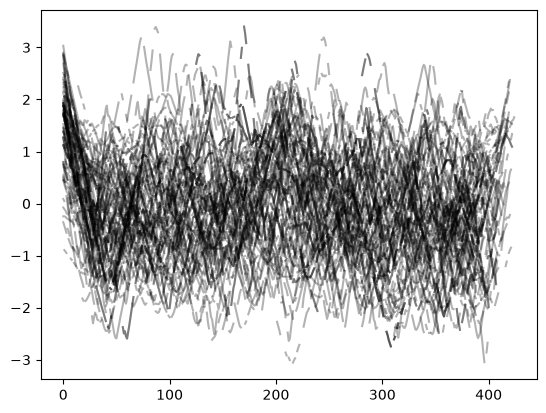

In [87]:
# plot 10 random samples
for s in ts_data_unp_heter.sample(n=100)['sample']:
    tsv = ts_data_unp_heter.query(f'sample=={s}')['value']
    tst = ts_data_unp_heter.query(f'sample=={s}')['Time']

    plt.plot(tst, tsv, color='black', alpha=0.3);

In [88]:
ts_data_unp_heter

,sample,Time,value
0,0,0,0.550671
442,0,1,NaN
884,0,2,0.375261
1326,0,3,NaN
1768,0,4,0.206427
...,...,...,...
167959,441,379,0.448389
168401,441,380,0.476657
168843,441,381,0.497787
169285,441,382,0.531158


In [89]:
nunique_samples = ts_data_unp_heter['sample'].nunique()
rand_selection = np.random.choice(ts_data_unp_heter['sample'].unique(), size=nunique_samples)
TSCluster.fit(ts_data_unp_heter.loc[ts_data_unp_heter['sample'].isin(rand_selection)])

  0%|          | 0/282 [00:00<?, ?it/s]\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  def normalise_ts(
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  def normalise_ts(
\\DS.UMCUTRECHT.NL\DATA\LAB\laupodteam\AIOS\Bram\production\TimEx\src\timex\preprocessing.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be rem

TSDistanceBasedClustering(add_ts_meta=True, cross_standardisation=True,
                          id_column='sample', imputation_kwargs={},
                          imputation_method='knn', interpolation=True,
                          interpolation_kwargs={}, max_time=450,
                          min_measurements_per_id=5, min_time=1,
                          model_kwargs={}, n_clusters=6, n_skip=2,
                          normalise_timeseries='group', smoothing_kwargs={},
                          smoothing_window_size=7, time_column='Time',
                          value_columns=['value'])

In [90]:
res_cluster = pd.DataFrame(zip(TSCluster.index_, TSCluster.labels_), columns=['ID', 'cluster'])
res_cluster['cluster'] = res_cluster['cluster'].astype(int)
res_final = ts_data_unp_heter.merge(res_cluster, how='left', left_on='sample', right_on='ID').dropna(subset='ID')
res_final = res_final.merge(ts_label_df, how='left', left_on='sample', right_on='sample')

<Axes: xlabel='Time', ylabel='value'>

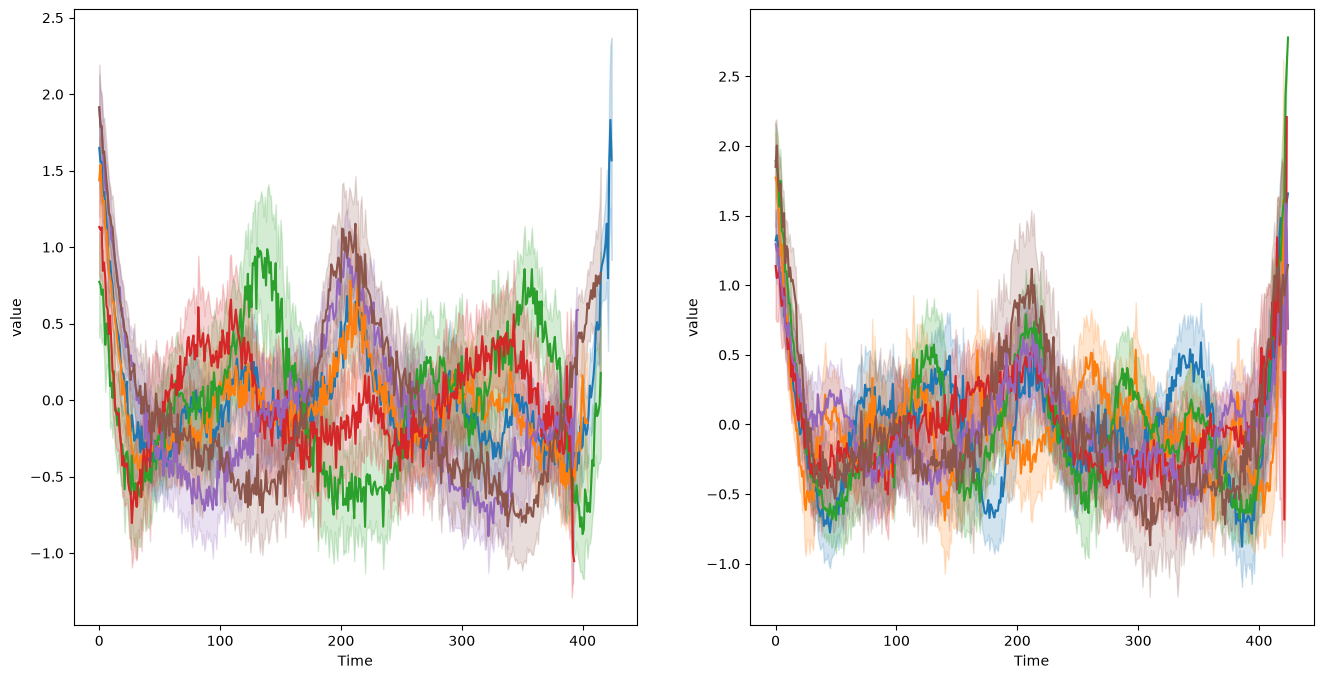

In [91]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='cluster',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[0],
             legend=False,)
sns.lineplot(data=res_final,
             x='Time', 
             y='value',
             hue='label',
             err_style='band',
             errorbar='ci',
             palette="tab10",
             ax=ax[1],
             legend=False,)

c:\Users\bes3\AppData\Local\pypoetry\Cache\virtualenvs\timex-6QUUgBf4-py3.12\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


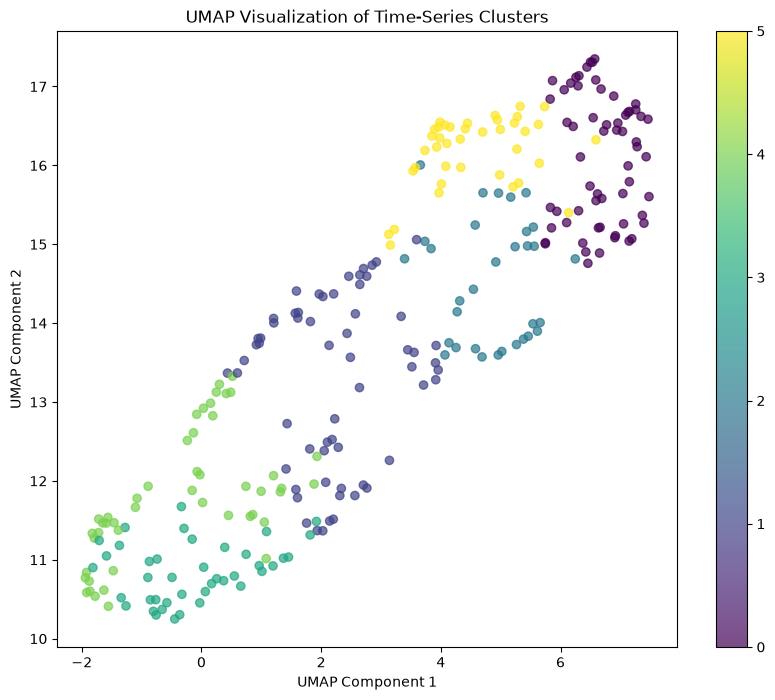

array([[ 0.03743741, 10.905543  ],
       [ 6.593415  , 15.553466  ],
       [ 6.917338  , 15.1079    ],
       [ 4.994774  , 16.45525   ],
       [ 5.539991  , 13.991921  ],
       [-1.0755582 , 11.779388  ],
       [-1.3407665 , 10.519486  ],
       [ 6.5007086 , 17.309967  ],
       [-1.2758284 , 11.409073  ],
       [-0.89499223, 10.77537   ],
       [-0.2910935 , 11.3975935 ],
       [ 6.293181  , 17.00866   ],
       [-0.07935341, 12.843794  ],
       [ 3.5356464 , 15.930286  ],
       [ 2.1048586 , 12.49146   ],
       [ 6.441857  , 17.24595   ],
       [ 6.25855   , 17.117647  ],
       [ 6.102682  , 15.274803  ],
       [ 1.3394483 , 11.905038  ],
       [ 3.7114463 , 13.215323  ],
       [ 3.9864154 , 16.547224  ],
       [-1.8643559 , 10.601449  ],
       [ 1.2048805 , 12.066394  ],
       [ 4.154909  , 16.485975  ],
       [ 0.9652355 , 10.925885  ],
       [ 5.3265576 , 16.748547  ],
       [ 0.24874602, 13.125641  ],
       [-0.15478699, 11.261626  ],
       [ 6.302064  ,

In [92]:
TSCluster.viz()